# Counting Markers in Video
In this notebook, we load a video, run our trained marker detector with built-in tracking (ByteTrack/BoT-SORT), and count the unique markers as they appear and disappear from the frames.

In [1]:
import cv2
from ultralytics import YOLO

# Load the trained marker detector model (using your trained weights e.g., 'yolov8s.pt' or 'yolo26s.pt')
# Update with your actual path to the trained weights
model = YOLO('runs/detect/runs/detect/marker_detector/weights/best.pt')

### Handling Multiple Detections (ID Switching)
When dealing with identical-looking markers, tracking algorithms like ByteTrack or BoT-SORT can sometimes lose a tracker ID (e.g., due to water splashes, occlusions by a swimmer, or the marker slightly rotating) and assign it a brand new ID when it reappears over the next few frames.

**Our Options to Mitigate Multiple Counting:**
1. **Spatial Deduplication (Implemented below)**: Identify new YOLO tracker IDs, but check their coordinates. If a "new" ID pops up very close to where a previous ID was last seen, assume it's the exact same marker and merge their counts. This works exceptionally well for relatively stationary objects like lane rope markers.
2. **Line Crossing Counters**: Only count a marker when its bounding box centroid crosses a specific line segment drawn in the frame. `ultralytics.solutions.ObjectCounter` natively supports this. This is ideal if the camera is constantly moving across the pool and markers pass by.
3. **Tracker Hyperparameter Tuning**: In `bytetrack.yaml`, increasing the `track_buffer` value (e.g., from 30 frames to 120 frames). This forces the tracker to remember "lost" tracks for a longer duration before declaring them dead, which reduces ID switching.
4. **Global Track Matching**: Overlap tracker data with camera motion data (Optical Flow) to establish a global coordinate system, letting us know where a marker sits globally in the pool, rather than locally on the frame.

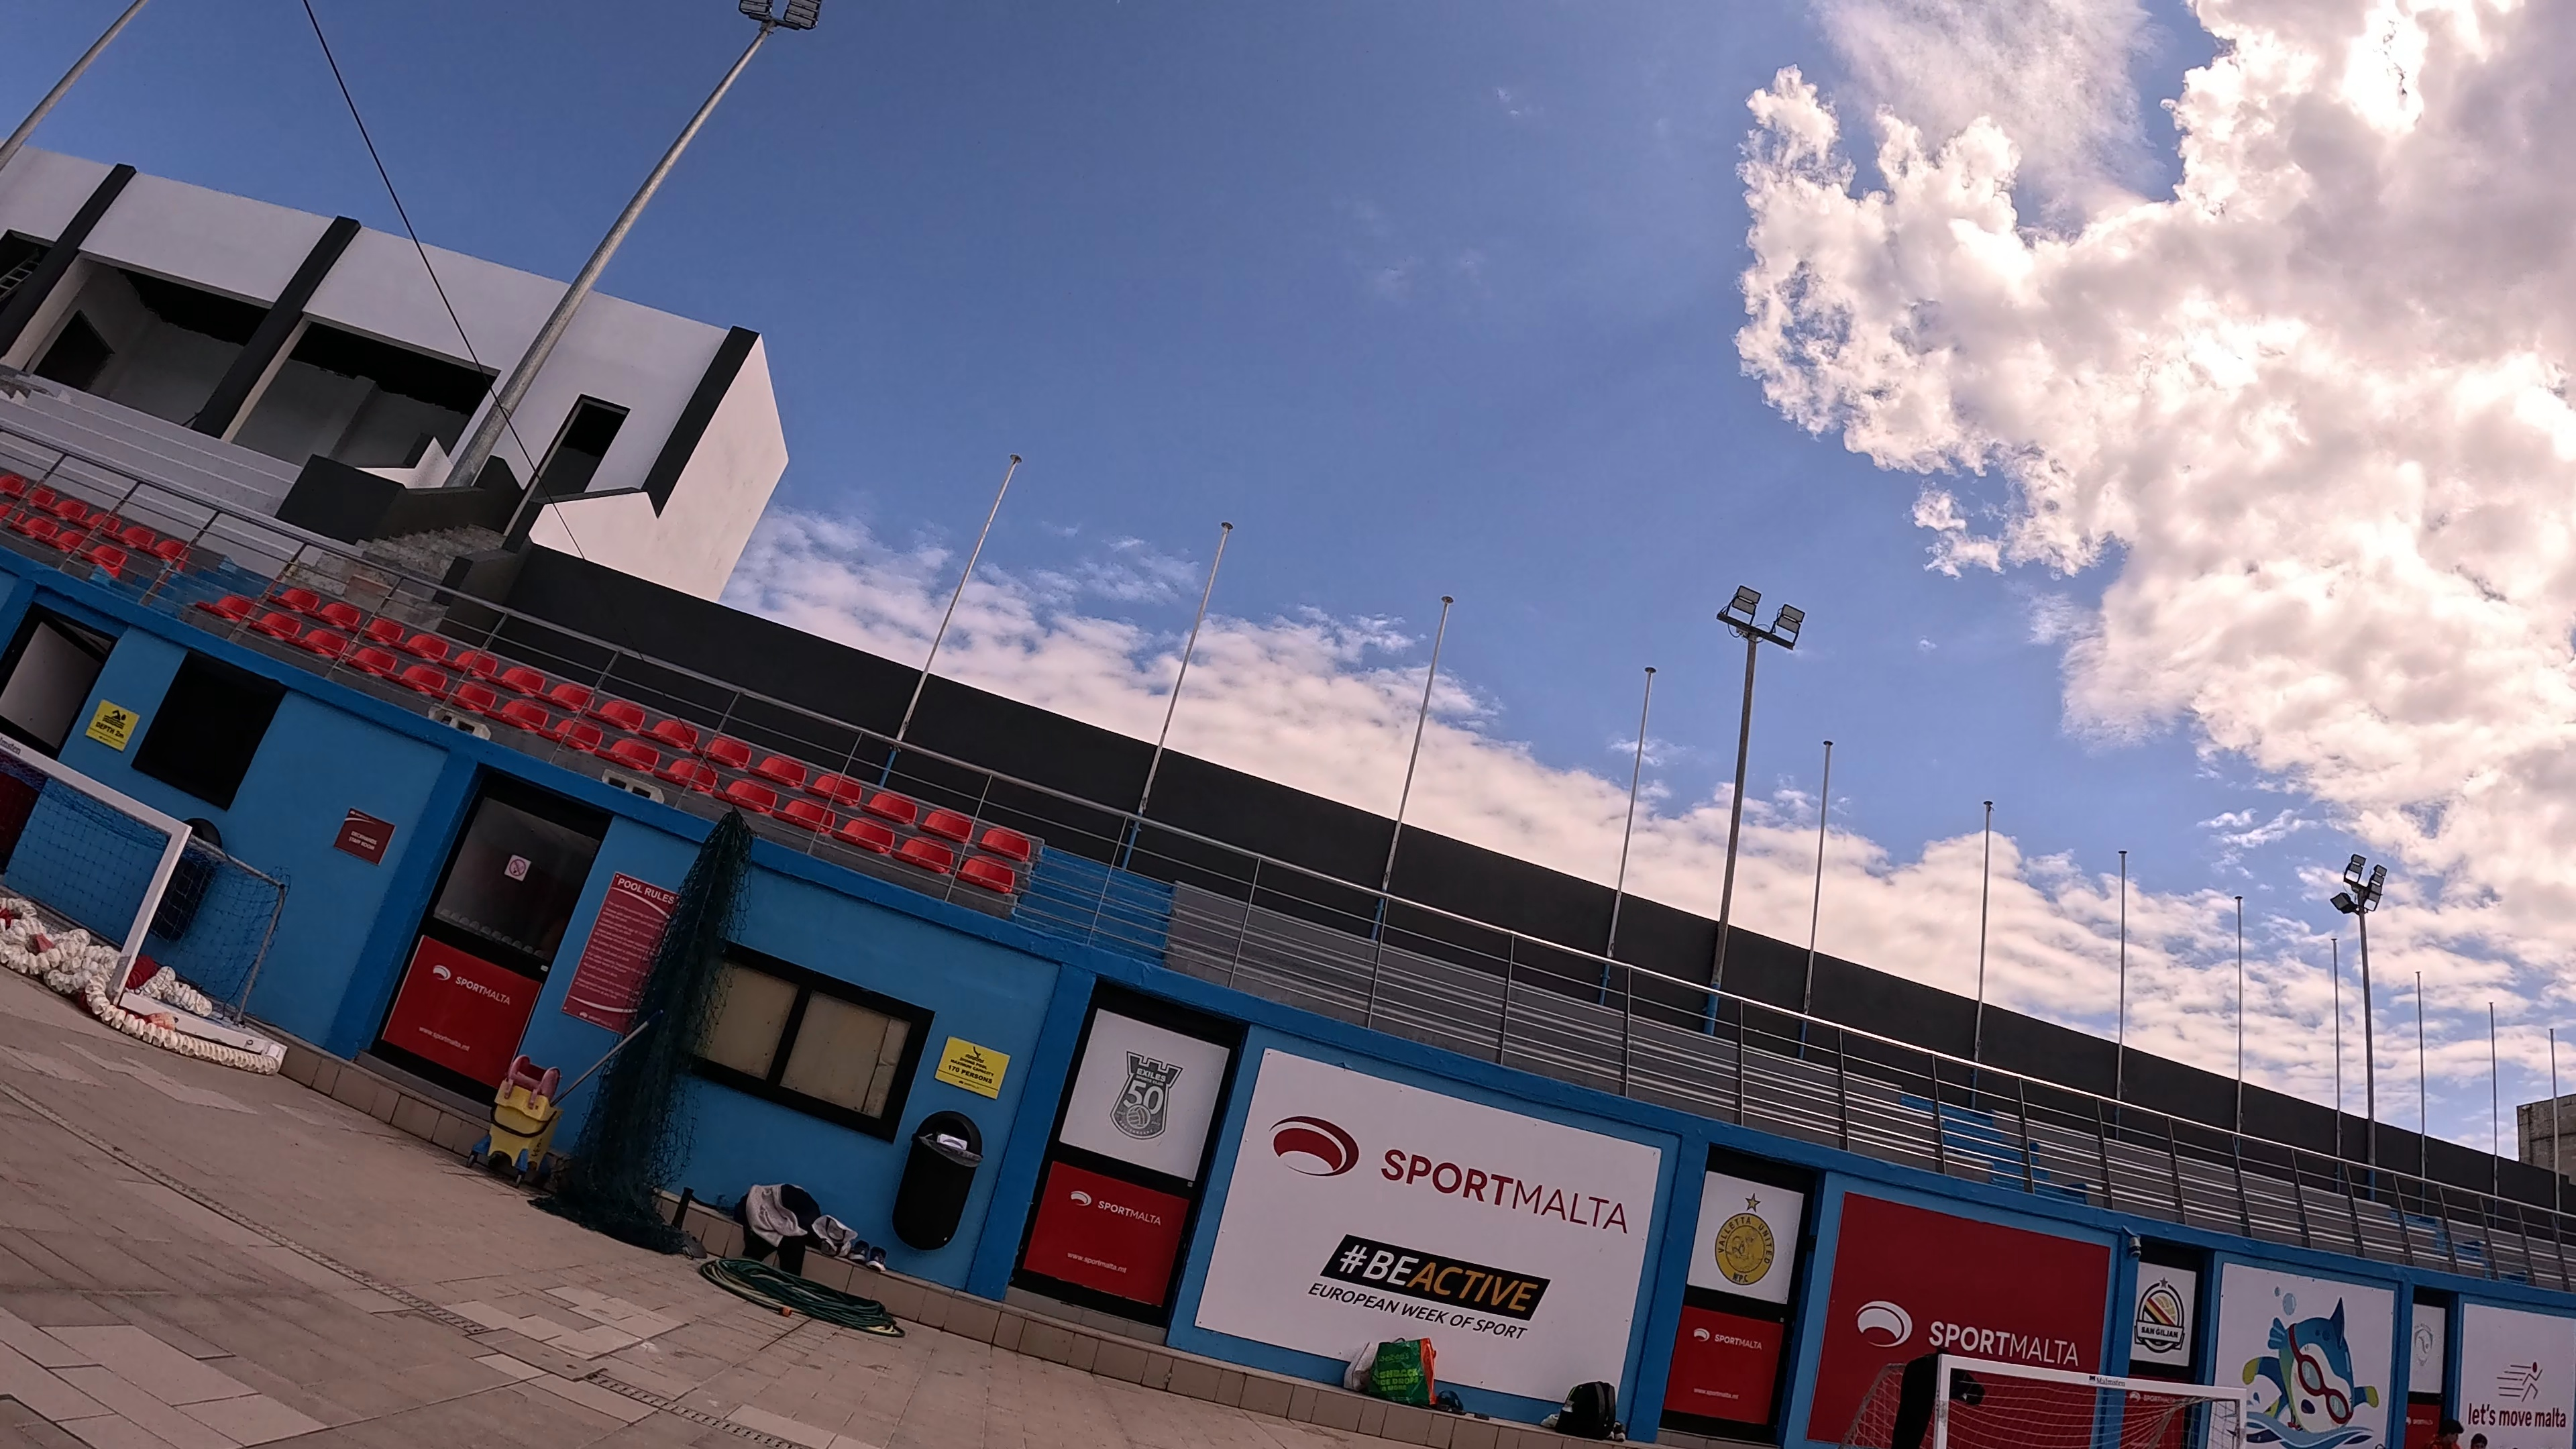

In [4]:
import math
from IPython.display import display, Image, clear_output

# Open the video file (update the path to one of your actual videos)
video_path = 'videos/under/Bottom_Butterfly_P034_1.MP4'
cap = cv2.VideoCapture(video_path)

# Dictionary to keep track of counted IDs (unique markers)
counted_ids = set()

# Maps a canonical (true) ID to its last known position (cx, cy)
known_markers = {}
# Maps YOLO's sometimes-changing tracker ID to our canonical ID
canonical_id_map = {}
next_canonical_id = 0
# Distance threshold (in pixels) to consider a "new" track as an existing marker
DISTANCE_THRESHOLD = 50 

frame_count = 0
while cap.isOpened():
    success, frame = cap.read()
    if not success:
        break
    
    frame_count += 1
    
    # Run YOLO object tracking on the frame, persisting tracks between frames
    results = model.track(frame, persist=True, tracker="bytetrack.yaml", verbose=False)
    
    # Check if any objects were tracked in this frame
    if results[0].boxes is not None and results[0].boxes.id is not None:
        boxes = results[0].boxes.xyxy.cpu().numpy()
        track_ids = results[0].boxes.id.int().cpu().tolist()
        
        for box, trk_id in zip(boxes, track_ids):
            # Calculate center of the bounding box
            cx = (box[0] + box[2]) / 2
            cy = (box[1] + box[3]) / 2
            
            if trk_id not in canonical_id_map:
                # This is a new track ID from YOLO. Check if it's close to a known marker.
                matched_c_id = None
                for c_id, last_pos in known_markers.items():
                    dist = math.hypot(cx - last_pos[0], cy - last_pos[1])
                    if dist < DISTANCE_THRESHOLD:
                        matched_c_id = c_id
                        break
                
                if matched_c_id is not None:
                    # It's an existing marker that temporarily lost its track
                    canonical_id_map[trk_id] = matched_c_id
                else:
                    # It's a genuinely new marker
                    canonical_id_map[trk_id] = next_canonical_id
                    next_canonical_id += 1
            
            # Get the resolved true ID and update its last known position
            canonical_id = canonical_id_map[trk_id]
            known_markers[canonical_id] = (cx, cy)
            counted_ids.add(canonical_id)
            
    # --- Visualization Code (Inline Display for Notebooks) ---
    annotated_frame = results[0].plot()
    
    # Encode the frame as a JPEG
    _, encoded_image = cv2.imencode('.jpeg', annotated_frame)
    display_img = Image(data=encoded_image)
    
    # Clear the previous output and display the new frame
    clear_output(wait=True)
    display(display_img)

cap.release()

In [5]:
print(f"Total frames processed: {frame_count}")
print(f"Total unique markers counted: {len(counted_ids)}")

Total frames processed: 2788
Total unique markers counted: 48


### Alternative Method 1: Virtual Tripwire / Line Crossing (Most Accurate)
If your camera is panning across the pool, or the markers are moving across the field of view, spatial distance deduplication will fail because the *entire background is moving*. 

The industry standard to fix this is a **Virtual Tripwire**.
We define a line across the frame. We only count a marker when its track crosses this line. Even if YOLO switches IDs before or after the line, the marker only physically crosses the line *once*, yielding a perfect count.

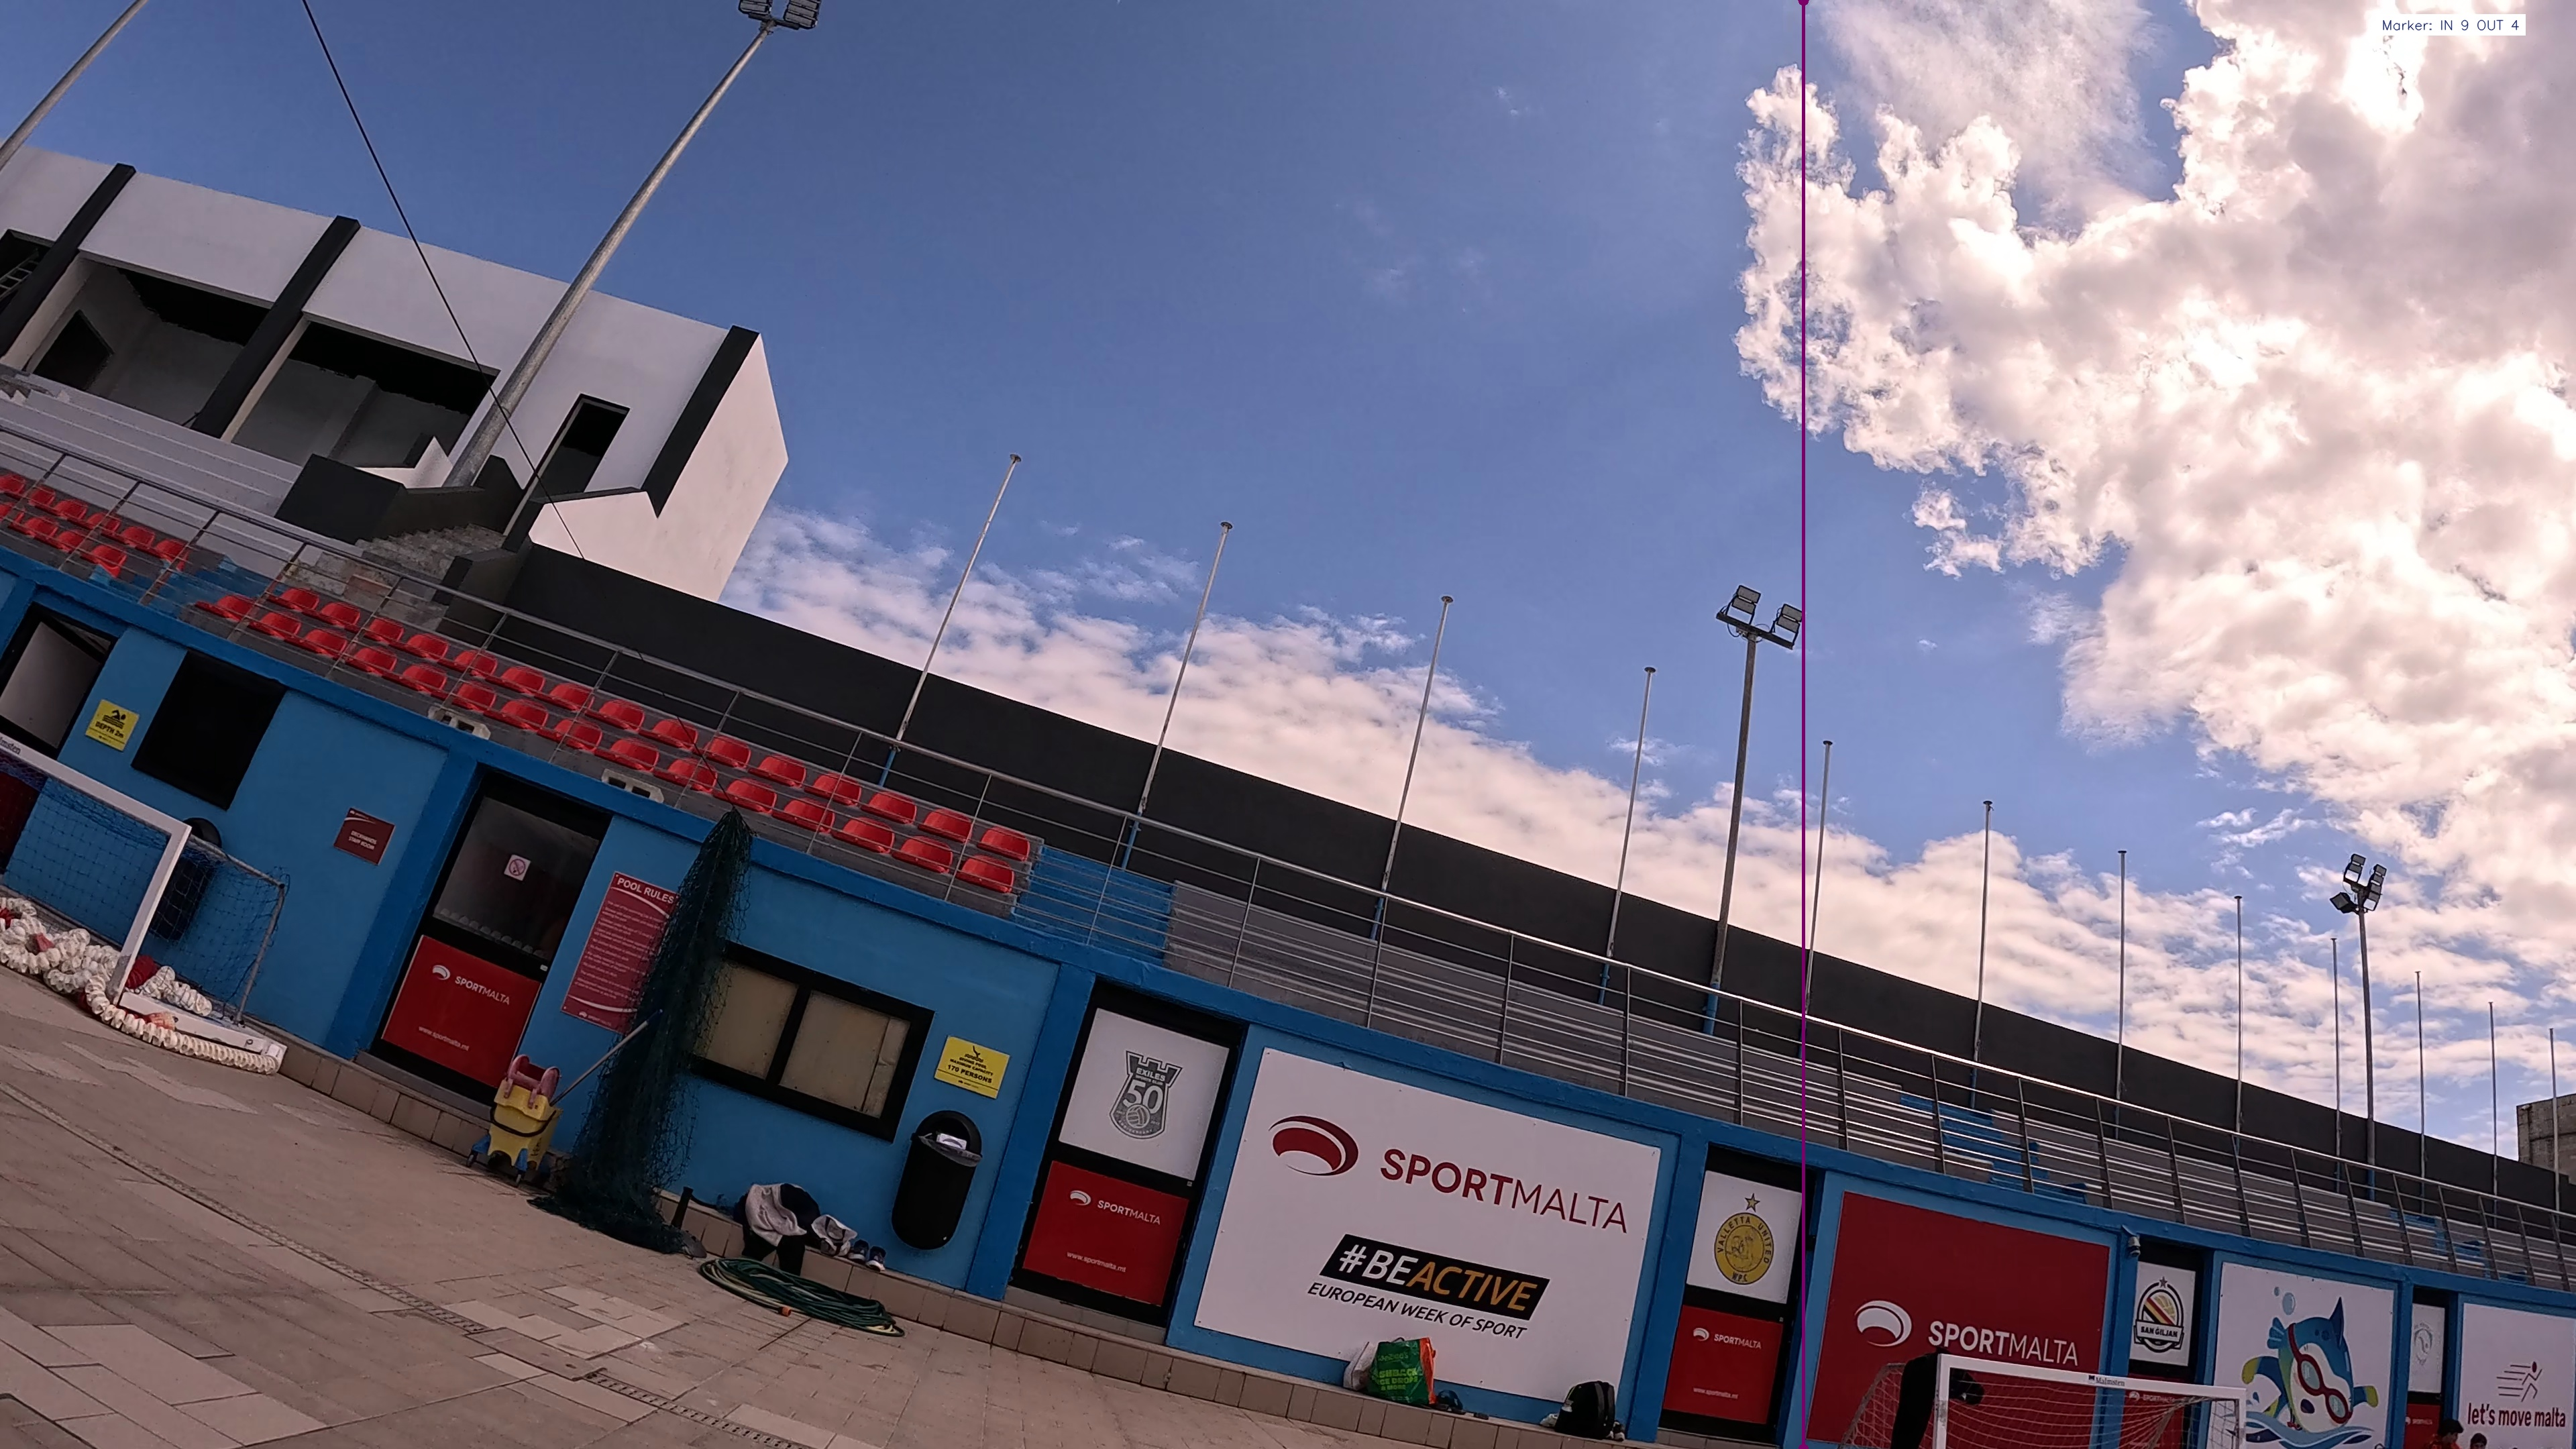

Current Count: 13
WARNING ⚠️ No tracks found.
2787: 2160x3840 2.0ms, 
Speed: 128.0ms track, 2.0ms solution per image at shape (1, 3, 2160, 3840)


--- Final Results ---
Total Unique Markers Counted (crossed line): 13


In [3]:
from ultralytics import solutions

# Initialize video
cap = cv2.VideoCapture(video_path)

# Use model path if available; fallback to model object
model_source = model.ckpt_path if hasattr(model, "ckpt_path") else model

# Initialize Ultralytics Object Counter (current API uses `region`, not `reg_pts`)
counter = solutions.ObjectCounter(
    model=model_source,
    region=line_points,
    tracker="botsort.yaml",
    line_width=2,
    show=False
)

frame_count = 0

while cap.isOpened():
    success, frame = cap.read()
    if not success:
        break
        
    frame_count += 1
    
    # Run counting (detection + tracking + line crossing)
    results = counter(frame)
    plotted_frame = results.plot_im
    
    # --- Visualization Code (Inline Display for Notebooks) ---
    # We'll only display every 3rd frame to keep Notebook running smoothly
    if frame_count % 3 == 0:
        _, encoded_image = cv2.imencode('.jpeg', plotted_frame)
        display_img = Image(data=encoded_image)
        
        clear_output(wait=True)
        display(display_img)
        print(f"Current Count: {results.out_count + results.in_count}")

cap.release()

print("\n--- Final Results ---")
print(f"Total Unique Markers Counted (crossed line): {counter.out_count + counter.in_count}")

### Alternative Method 2: Global Maximum Detections
If your video is short, or if *all 9 markers are visible at once* at some point during the panning, the most robust way to count them is to simply find the maximum number of bounding boxes the model detected in any single frame. No tracking ID logic needed.

In [ ]:
cap = cv2.VideoCapture(video_path)

max_markers_seen = 0

while cap.isOpened():
    success, frame = cap.read()
    if not success:
        break
        
    # Standard detection (no track required)
    results = model.predict(frame, verbose=False)
    
    # Get the number of boxes in THIS specific frame
    current_frame_markers = len(results[0].boxes)
    if current_frame_markers > max_markers_seen:
        max_markers_seen = current_frame_markers

cap.release()
print(f"Absolute max markers seen in a single frame: {max_markers_seen}")